Import the library.

In [4]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, Flatten

Load the data and plot an sample data.

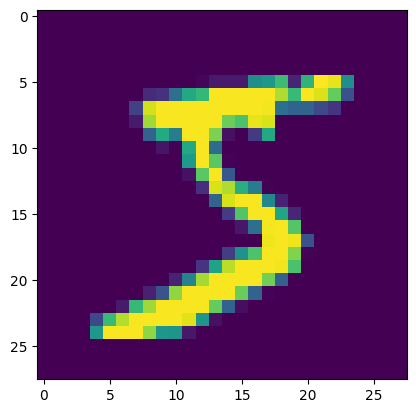

In [5]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()  # Load the MNIST dataset
import matplotlib.pyplot as plt

plt.imshow(X_train[0])  # Display the first image in the training set

Normalize the train and test data.

In [6]:
X_train = X_train / 255.0  # Normalize the training images to the range [0, 1]
X_test = X_test / 255.0    # Normalize the test images to the range [0, 1]

In [7]:
X_train[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Make an ANN model and print the summary with total trainable parameter.

In [8]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))  # Flatten the input images from 28x28 to a 1D array of size 784
model.add(Dense(128, activation='relu'))  # Add a dense layer with 128 neurons and ReLU activation
model.add(Dense(10, activation='softmax'))  # Add a dense layer with 10 neurons and softmax activation
model.summary()  # Print the model summary to see the architecture and number of parameters

/home/hardik/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1782565379.333348  129650 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Compile and train the model.

In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Compile the model with Adam optimizer, sparse categorical cross-entropy loss function, and accuracy metric.
history = model.fit(X_train, y_train, epochs=25, batch_size=25, validation_split=0.2)  # Train the model on the training data for 25 epochs with a batch size of 25 and a validation split of 20%.

Epoch 1/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9214 - loss: 0.2752 - val_accuracy: 0.9477 - val_loss: 0.1689
Epoch 2/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9631 - loss: 0.1222 - val_accuracy: 0.9669 - val_loss: 0.1122
Epoch 3/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0838 - val_accuracy: 0.9722 - val_loss: 0.0922
Epoch 4/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9819 - loss: 0.0602 - val_accuracy: 0.9699 - val_loss: 0.0996
Epoch 5/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0461 - val_accuracy: 0.9753 - val_loss: 0.0883
Epoch 6/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9883 - loss: 0.0379 - val_accuracy: 0.9768 - val_loss: 0.0877
Epoch 7/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9909 - loss: 0.0292 - val_accuracy: 0.9750 - val_loss: 0.0957
Epoch 8/25
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9928 - loss: 0.0230 - 

Find the predicted value and find the accuracy score.

In [10]:
y_proba = model.predict(X_test)  # Predict the class probabilities for the test set
y_pred = y_proba.argmax(axis=1)  # Get the predicted class labels

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)  # Calculate the accuracy of the model on the test set
print(f"Test accuracy: {accuracy:.4f}")  # Print the test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test accuracy: 0.9769


Plot the accuracy and loss and their validation value against epochs.

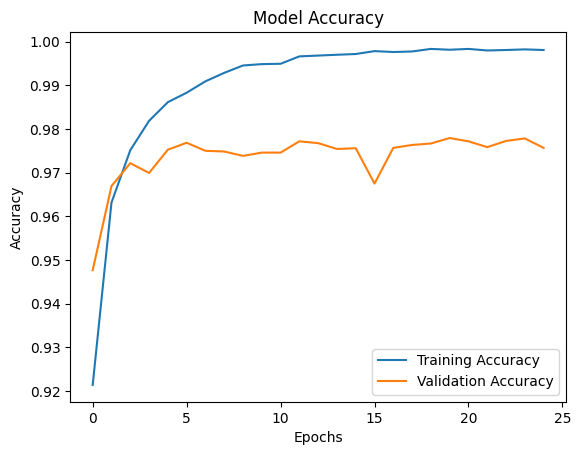

In [11]:
plt.plot(history.history['accuracy'], label='Training Accuracy')  # Plot the training accuracy over epochs
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Plot the validation accuracy over epochs
plt.title('Model Accuracy')  # Set the title of the plot
plt.xlabel('Epochs')  # Set the x-axis label
plt.ylabel('Accuracy')  # Set the y-axis label
plt.legend()  # Show the legend

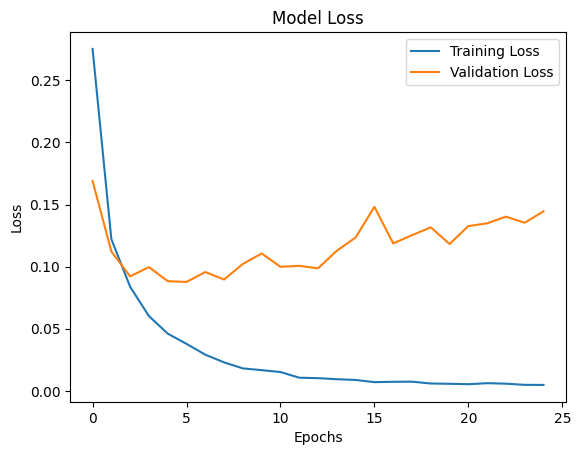

In [12]:
plt.plot(history.history['loss'], label='Training Loss')  # Plot the training loss over epochs
plt.plot(history.history['val_loss'], label='Validation Loss')  # Plot the validation loss over epochs
plt.title('Model Loss')  # Set the title of the plot
plt.xlabel('Epochs')  # Set the x-axis label
plt.ylabel('Loss')  # Set the y-axis label
plt.legend()  # Show the legend